Image Sharpening

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
def gaussian_kernel(size, sigma):
    k = size // 2
    x, y = np.mgrid[-k:k+1, -k:k+1]
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return kernel

In [ ]:
def gaussian_blur_gray(image, size=5, sigma=1.0):
    kernel = gaussian_kernel(size, sigma)
    pad = size // 2

    padded = np.pad(image, pad_width=pad, mode='reflect')
    blurred = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+size, j:j+size]
            blurred[i, j] = np.sum(region * kernel)

    return blurred

In [ ]:
def unsharp_mask_gray(image, size=5, sigma=1.0, alpha=1.0):
    image_f = image.astype(np.float32)
    blurred = gaussian_blur_gray(image, size=size, sigma=sigma)

    sharpened = image_f + alpha * (image_f - blurred)
    sharpened = np.clip(sharpened, image.min(), image.max())

    return sharpened.astype(image.dtype)

In [ ]:
def unsharp_mask_color(image, size=5, sigma=1.0, alpha=1.0):
    # Convert RGB → YCrCb
    ycrcb = cv2.cvtColor(image, cv2.COLOR_RGB2YCrCb)
    Y, Cr, Cb = cv2.split(ycrcb)

    # Sharpen only luminance
    Y_f = Y.astype(np.float32)
    Y_blur = gaussian_blur_gray(Y, size=size, sigma=sigma)

    Y_sharp = Y_f + alpha * (Y_f - Y_blur)
    Y_sharp = np.clip(Y_sharp, Y.min(), Y.max()).astype(np.uint8)

    # Merge back
    ycrcb_sharp = cv2.merge([Y_sharp, Cr, Cb])

    # Convert back to RGB
    return cv2.cvtColor(ycrcb_sharp, cv2.COLOR_YCrCb2RGB)

In [ ]:
def unsharp_mask(image, size=5, sigma=1.0, alpha=1.0):
    if image.ndim == 2:
        return unsharp_mask_gray(image, size, sigma, alpha)
    elif image.ndim == 3:
        return unsharp_mask_color(image, size, sigma, alpha)
    else:
        raise ValueError("Unsupported image format")

In [ ]:
images = {
    "Moon": cv2.imread("/content/moon.png", cv2.IMREAD_GRAYSCALE),
    "Peacock": cv2.cvtColor(
        cv2.imread("/content/peacock.png"), cv2.COLOR_BGR2RGB
    ),
    "Tiger": cv2.cvtColor(
        cv2.imread("/content/tiger.png"), cv2.COLOR_BGR2RGB
    )
}

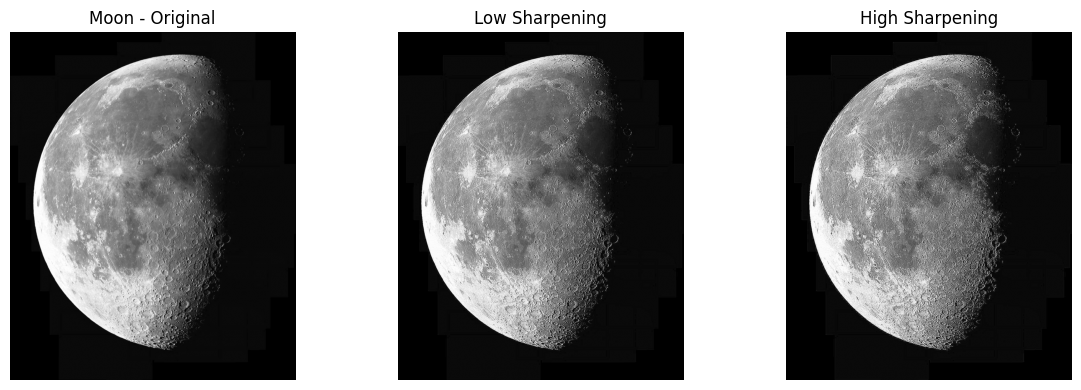

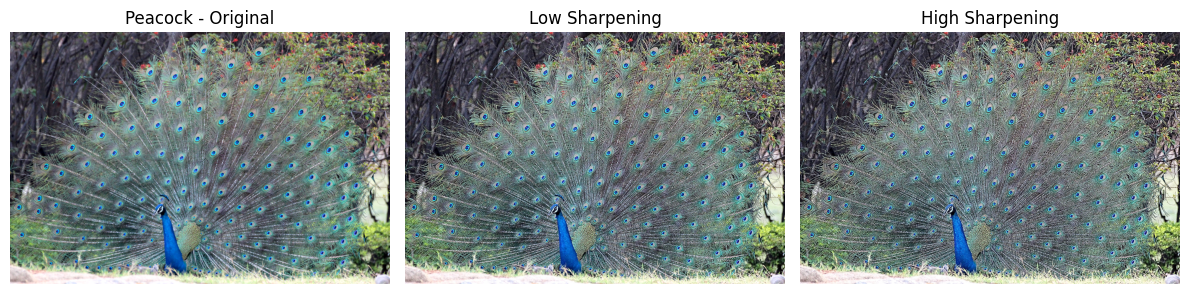

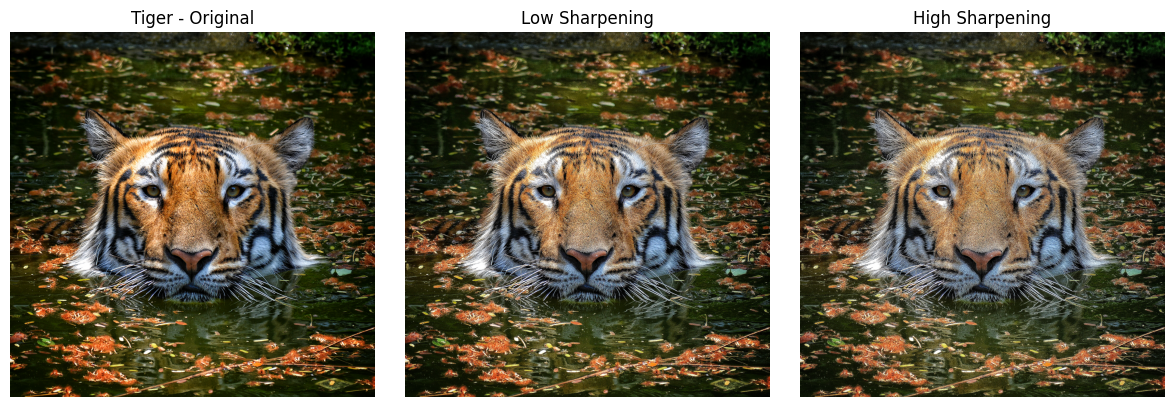

In [ ]:
for name, img in images.items():
    sharp_low = unsharp_mask(img, sigma=1.0, alpha=5)
    sharp_high = unsharp_mask(img, sigma=1.0, alpha=10)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img if img.ndim == 3 else img, cmap=None if img.ndim == 3 else 'gray')
    plt.title(f"{name} - Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(sharp_low if sharp_low.ndim == 3 else sharp_low,
               cmap=None if sharp_low.ndim == 3 else 'gray')
    plt.title("Low Sharpening")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(sharp_high if sharp_high.ndim == 3 else sharp_high,
               cmap=None if sharp_high.ndim == 3 else 'gray')
    plt.title("High Sharpening")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Template Matching

In [ ]:
def ncc_single_channel(patch, template):
  patch = patch.astype(np.float32)
  template = template.astype(np.float32)

  patch_mean = np.mean(patch)
  template_mean = np.mean(template)

  numerator = np.sum((patch - patch_mean) * (template - template_mean))
  denominator = np.sqrt(np.sum((patch - patch_mean)**2) * np.sum((template - template_mean)**2))

  if denominator == 0:
    return 0

  return numerator / denominator

In [ ]:
def template_match_ncc_rgb(scene, template):
  H, W, _ = scene.shape
  h, w, _ = template.shape

  ncc_map = np.zeros((H - h + 1, W - w + 1), dtype=np.float32)

  for i in range(H-h+1):
    for j in range(W-w+1):
      patch = scene[i:i+h, j:j+w, :]

      ncc_r = ncc_single_channel(patch[:, :, 0], template[:, :, 0])
      ncc_g = ncc_single_channel(patch[:, :, 1], template[:, :, 1])
      ncc_b = ncc_single_channel(patch[:, :, 2], template[:, :, 2])

      ncc_map[i, j] = (ncc_r + ncc_g + ncc_b)/3.0

  return ncc_map

In [ ]:
scene = cv2.cvtColor(
    cv2.imread("/content/parking.png"),
    cv2.COLOR_BGR2RGB
)

template = cv2.cvtColor(
    cv2.imread("/content/templateNoPark.png"),
    cv2.COLOR_BGR2RGB
)

In [ ]:
ncc_map = template_match_ncc_rgb(scene, template)

y, x = np.unravel_index(np.argmax(ncc_map), ncc_map.shape)
print("Best match Location:", (x, y))
print("Best NCC score:", ncc_map[y, x])

KeyboardInterrupt: 

In [ ]:
# Best match location
y, x = np.unravel_index(np.argmax(ncc_map), ncc_map.shape)

plt.figure(figsize=(6, 5))
plt.imshow(ncc_map, cmap='jet')
plt.colorbar(label='NCC Score')
plt.scatter(x, y, c='white', s=50, marker='x')
plt.title('NCC Map with Best Match')
plt.xlabel('x (columns)')
plt.ylabel('y (rows)')
plt.show()

In [ ]:
h, w, _ = template.shape

scene_vis = scene.copy()

plt.figure(figsize=(8, 6))
plt.imshow(scene_vis)
plt.gca().add_patch(
    plt.Rectangle(
        (x, y), w, h,
        edgecolor='red',
        facecolor='none',
        linewidth=2
    )
)
plt.title('Best Template Match in Scene')
plt.axis('off')
plt.show()

In [ ]:
# Reduce scene size by factor of 5
scene_small = cv2.resize(
    scene,
    (scene.shape[1] // 5, scene.shape[0] // 5),
    interpolation=cv2.INTER_AREA
)

template_sizes = [41, 51, 61]

In [ ]:
def template_match_ncc_single_channel(scene_channel, template_channel):
    H, W = scene_channel.shape
    h, w = template_channel.shape

    ncc_map = np.zeros((H - h + 1, W - w + 1), dtype=np.float32)

    for i in range(H - h + 1):
        for j in range(W - w + 1):
            patch = scene_channel[i:i+h, j:j+w]
            ncc_map[i, j] = ncc_single_channel(patch, template_channel)

    return ncc_map

In [ ]:
for size in template_sizes:
    # Resize template
    template_resized = cv2.resize(
        template,
        (size, size),
        interpolation=cv2.INTER_AREA
    )

    # Split channels
    scene_R, scene_G, scene_B = cv2.split(scene_small)
    temp_R, temp_G, temp_B = cv2.split(template_resized)

    # Compute NCC maps
    ncc_R = template_match_ncc_single_channel(scene_R, temp_R)
    ncc_G = template_match_ncc_single_channel(scene_G, temp_G)
    ncc_B = template_match_ncc_single_channel(scene_B, temp_B)

    # Display results
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(ncc_R, cmap='jet')
    plt.colorbar()
    plt.title(f'Red Channel NCC (Template {size}×{size})')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(ncc_G, cmap='jet')
    plt.colorbar()
    plt.title(f'Green Channel NCC (Template {size}×{size})')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(ncc_B, cmap='jet')
    plt.colorbar()
    plt.title(f'Blue Channel NCC (Template {size}×{size})')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Canny Edge Detection

In [ ]:
def gaussian_blur(image, size=5, sigma=1.4):
    kernel = gaussian_kernel(size, sigma)
    pad = size // 2
    padded = np.pad(image, pad, mode='reflect')
    blurred = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+size, j:j+size]
            blurred[i, j] = np.sum(region * kernel)

    return blurred

In [ ]:
def sobel_gradients(image):
  kx = np.array([
      [-1, 0, 1],
      [-2, 0, 2],
      [-1, 0, 1]
  ])

  ky = np.array([
      [1, 2, 2],
      [0, 0, 0],
      [-1, -2, -1]
  ])

  pad = 1
  padded = np.pad(image, pad, mode = 'reflect')

  Gx = np.zeros_like(image)
  Gy = np.zeros_like(image)

  for i in range(image.shape[0]):
    for j in range(image.shape[1]):
      region = padded[i:i+3, j:j+3]
      Gx[i, j] = np.sum(region * kx)
      Gy[i, j] = np.sum(region * ky)

  magnitude = np.sqrt(Gx**2 + Gy**2)
  magnitude = magnitude / magnitude.max() * 255

  direction = np.arctan2(Gy, Gx)

  return magnitude, direction

In [ ]:
def non_maximum_suppression(magnitude, angle):
  H, W = magnitude.shape
  nms = np.zeros((H, W), dtype=np.float32)

  angle = angle*180 / np.pi
  angle[angle < 0] += 180

  for i in range(1, H-1):
    for j in range(1, W-1):

      q = r = 0

      if(0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
        q = magnitude[i, j+1]
        r = magnitude[i, j-1]
      elif 22.5 <= angle[i, j] < 67.5:
        q = magnitude[i+1, j-1]
        r = magnitude[i-1, j+1]
      elif 67.5 <= angle[i, j] < 112.5:
        q = magnitude[i+1, j-1]
        r = magnitude[i-1, j+1]
      elif 112.5 <= angle[i, j] < 157.5:
        q = magnitude[i-1, j-1]
        r = magnitude[i+1, j+1]

      if magnitude[i, j] >= q and magnitude[i, j] >= r:
        nms[i, j] = magnitude[i, j]
      else:
        nms[i, j] = 0

  return nms

In [ ]:
def hysteresis_threshold(image, low, high):
  strong = 255
  weak = 75

  result = np.zeros_like(image, dtype=np.uint8)

  strong_i, strong_j = np.where(image >= high)
  weak_i, weak_j = np.where((image >= low) & (image < high))

  result[strong_i, strong_j] = strong
  result[weak_i, weak_j] = weak

  for i in range(1, image.shape[0]-1):
    for j in range(1, image.shape[1]-1):
      if result[i, j] == weak:
        if np.any(result[i-1:i+2, j-1:j+2] == strong):
          result[i, j] = strong
        else:
          result[i, j] = 0


  return result

In [ ]:
def canny_edge_detector(image, low_thresh=50, high_thresh=120):
  blurred = gaussian_blur(image, sigma=1.4)
  mag, angle = sobel_gradients(blurred)
  nms = non_maximum_suppression(mag, angle)
  result = hysteresis_threshold(nms, low_thresh, high_thresh)

  return result

In [ ]:
image_paths = [
    "/content/butterfly.png",
    "/content/paithaniEdge.png",
    "/content/rangoli.png"
]

In [ ]:
def thicken_edges(edges, thickness=2):
    kernel = np.ones((thickness, thickness), np.uint8)
    return cv2.dilate(edges, kernel, iterations=1)

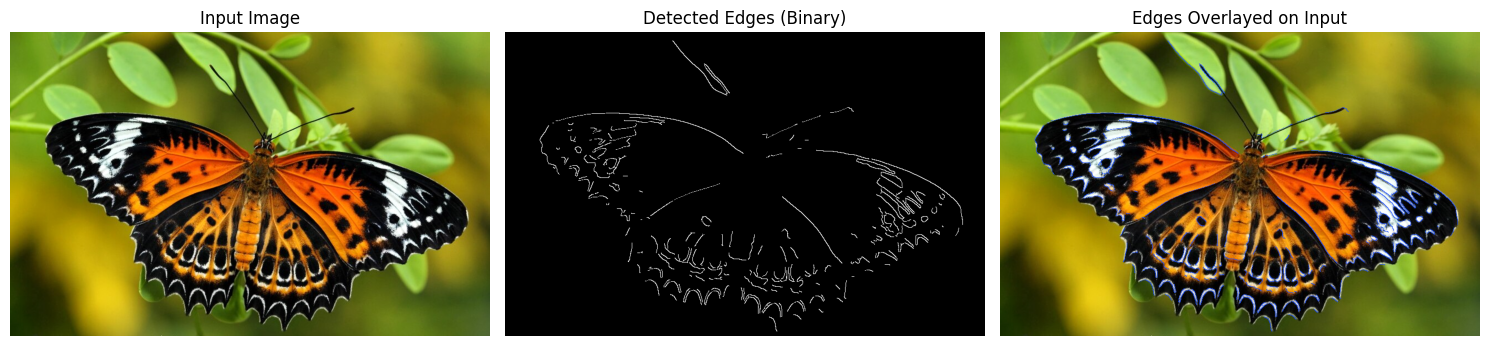

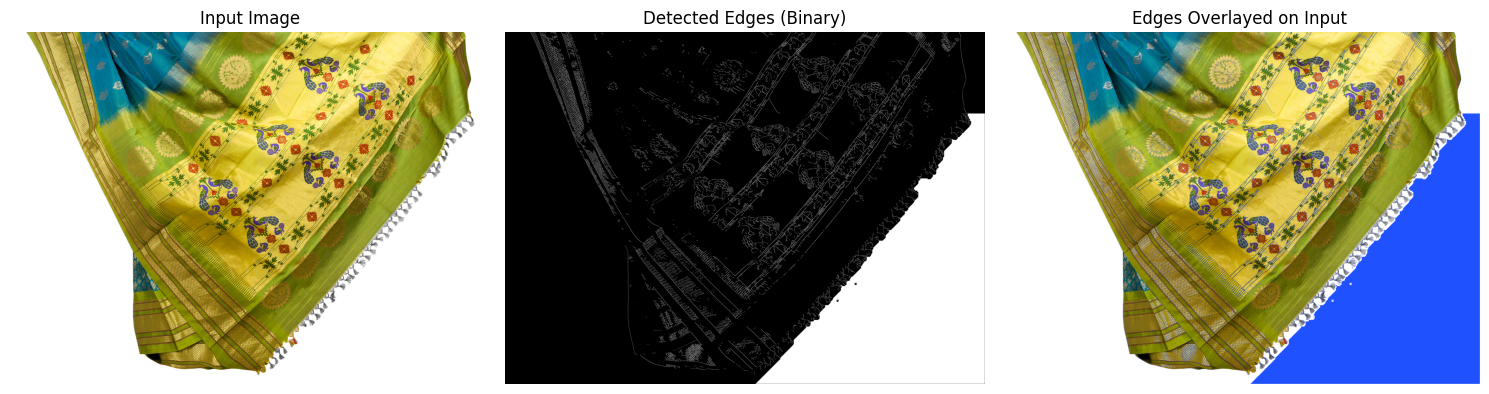

In [ ]:
for path in image_paths:
    img_color = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_RGB2GRAY)

    edges = canny_edge_detector(img_gray, low_thresh=50, high_thresh=120)
    edges_thick = thicken_edges(edges, thickness=5)

    # Overlay edges in black
    overlay = img_color.copy()
    overlay[edges == 255] = [31, 81, 255]

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img_color)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(edges, cmap='gray')
    plt.title("Detected Edges (Binary)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Edges Overlayed on Input")
    plt.axis("off")

    plt.tight_layout()
    plt.show()